#### Imports

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import os
import argparse
np.set_printoptions(precision=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


#### Util Functions

In [58]:
def set_npseed(seed):
	np.random.seed(seed)


def set_torchseed(seed):
	torch.manual_seed(seed)
	torch.cuda.manual_seed(seed)
	torch.cuda.manual_seed_all(seed)
	torch.backends.cudnn.deterministic = True
	torch.backends.cudnn.benchmark = False

def choose(a,c):
	return np.array([c[a[I]][I] for I in np.ndindex(a.shape)])


In [59]:
def return_output_vals(DLGN_obj, train_data_curr, train_labels_curr, device=device):
    train_outputs_values, train_outputs_gate_scores =DLGN_obj(torch.Tensor(train_data_curr).to(device))
    train_preds = train_outputs_values[-1]
    return train_preds.cpu().detach().numpy()

def give_loss(DLGN_obj, data_curr, labels_curr, device=device):
    outputs_values, outputs_gate_scores =DLGN_obj(torch.Tensor(data_curr).to(device))
    preds = outputs_values[-1]
    criterion = nn.BCEWithLogitsLoss()
    targets = torch.tensor(labels_curr, dtype=torch.float32).to(device).reshape(-1, 1)
    loss = criterion(preds, targets)
    return loss.cpu().detach().numpy()

def give_error(DLGN_obj, data_curr, labels_curr, device=device):
    outputs_values, outputs_gate_scores =DLGN_obj(torch.Tensor(data_curr).to(device))
    preds = outputs_values[-1]
    preds = preds.detach().cpu().numpy()
    error=np.sum(labels_curr != (np.sign(preds[:,0])+1)//2 )
    return error


#### Generate ODT Dataset

In [60]:
def data_gen_decision_tree(num_data=1000, dim=2, seed=0, w_list=None, b_list=None, 
							vals=None, num_levels=2):
	set_npseed(seed=seed)
	# Construct a complete decision tree with 2**num_levels-1 internal nodes, 
	# e.g. num_levels=2 means there are 3 internal nodes.
	# w_list, b_list is a list of size equal to num_internal_nodes
	# vals is a list of size equal to num_leaf_nodes, with values +1 or -1
	num_internal_nodes = 2**num_levels - 1
	num_leaf_nodes = 2**num_levels
	stats = np.zeros(num_internal_nodes+num_leaf_nodes)

	if vals is None:
		vals = np.arange(0,num_internal_nodes+num_leaf_nodes,1,dtype=np.int32)%2
		vals[:num_internal_nodes] = -99

	if w_list is None:
		w_list = np.random.standard_normal((num_internal_nodes, dim))
		w_list = w_list/np.linalg.norm(w_list, axis=1)[:, None]
		b_list = np.zeros((num_internal_nodes))
		Q,R = np.linalg.qr(w_list.T)
		w_list = Q.T

	data_x = np.random.standard_normal((num_data, dim))
	data_x /= np.sqrt(np.sum(data_x**2, axis=1, keepdims=True))
	relevant_stats = data_x @ w_list.T + b_list
	

	curr_index = np.zeros(shape=(num_data), dtype=int)
	
	for level in range(num_levels):
		nodes_curr_level=list(range(2**level - 1,2**(level+1)-1  ))
		for el in nodes_curr_level:
			relevant_stats[:,el] += b_list[el]
		decision_variable = choose(curr_index, relevant_stats.T) 
		# Go down and right if wx+b>0 down and left otherwise. 
		# i.e. 0 -> 1 if w[0]x+b[0]<0 and 0->2 otherwise
		curr_index = (curr_index+1)*2 - (1-(decision_variable > 0))

	bound_dist = np.min(np.abs(relevant_stats), axis=1)
	# thres = 0.02
	labels = vals[curr_index]
	relevant_stats = np.sign(data_x @ w_list.T + b_list)
	nodes_active = np.zeros((len(data_x),  num_internal_nodes+num_leaf_nodes), dtype=np.int32)
	for node in range(num_internal_nodes+num_leaf_nodes):
		if node==0:
			stats[node]=len(relevant_stats)
			nodes_active[:,0]=1
			continue
		parent = (node-1)//2
		nodes_active[:,node]=nodes_active[:,parent]
		right_child = node-(parent*2)-1 # 0 means left, 1 means right 1 has children 3,4
		if right_child==1:
			nodes_active[:,node] *= relevant_stats[:,parent]>0
		if right_child==0:
			nodes_active[:,node] *= relevant_stats[:,parent]<0		
		stats = nodes_active.sum(axis=0)
	return ((data_x, labels), (w_list, b_list, vals), stats)


num_data = 160000
input_dim=100
# random_integers is deprecated; randint(..., 10001, ...) preserves inclusive high=10000 behavior.
seeds = np.random.randint(0, 10001, 100)
seeds=[1387]
for seed in seeds:
	((data_x, labels), (w_list, b_list, vals), stats) = data_gen_decision_tree(
											dim=input_dim, seed=seed, num_levels=5,
											num_data=num_data)
	seed_set=seed

num_data = len(data_x)


w_list_old = np.array(w_list)
b_list_old = np.array(b_list)

print(data_x.shape)
print(labels.shape)

num_data = len(data_x)
num_train= num_data//2
num_vali = num_data//4
num_test = num_data//4
train_data = data_x[:num_train,:]
train_data_labels = labels[:num_train]

vali_data = data_x[num_train:num_train+num_vali,:]
vali_data_labels = labels[num_train:num_train+num_vali]

test_data = data_x[num_train+num_vali :,:]
test_data_labels = labels[num_train+num_vali :]

(160000, 100)
(160000,)


#### Hyper Parameters

In [61]:
class Args:
    def __init__(self):
        self.numlayer=5
        self.numnodes=16
        self.beta=11.
        self.lr = 0.001
        self.saved_epochs = list(range(0,2001,20))
        self.num_batches = 500


In [62]:
args =  Args()



#### DLGN Class

In [ ]:
class DLGN_FC(nn.Module):
	def __init__(self, input_dim=None, args=None):		
		super(DLGN_FC, self).__init__()
		self.num_hidden_layers = args.numlayer
		self.beta=args.beta  # Soft gating parameter
		num_hidden_nodes = [args.numnodes]*args.numlayer
		self.num_nodes=[input_dim]+num_hidden_nodes+[1]
		self.gating_layers=nn.ModuleList()
		self.value_layers=nn.ModuleList()
		
		for i in range(self.num_hidden_layers+1):
			if i!=self.num_hidden_layers:
				temp = nn.Linear(self.num_nodes[0], self.num_nodes[i+1], bias=False)
				self.gating_layers.append(temp)
			temp = nn.Linear(self.num_nodes[i], self.num_nodes[i+1], bias=False)
			self.value_layers.append(temp)



	def forward(self, x):
		gate_scores=[x]
		values=[torch.ones(x.shape).to(device)]
		
		for i in range(self.num_hidden_layers):
			gate_scores.append( (x@self.gating_layers[i].weight.T) )
			curr_gate_on_off = torch.sigmoid(self.beta * gate_scores[-1])
			values.append(self.value_layers[i](values[-1])*curr_gate_on_off)
		values.append(2*self.value_layers[self.num_hidden_layers](values[-1]))
		# Values is a list of size 1+num_hidden_layers+1
		#gate_scores is a list of size 1+num_hidden_layers
		return values,gate_scores

#### Train

In [64]:
def train_dlgn (DLGN_obj, train_data, train_labels,
				parameter_mask=dict(), args=None):
	DLGN_obj = DLGN_obj.to(device)

	criterion = nn.BCEWithLogitsLoss()
	optimizer = optim.Adam(DLGN_obj.parameters(), lr=args.lr)


	train_data_torch = torch.Tensor(train_data)
	train_labels_torch = torch.tensor(train_labels, dtype=torch.float32).reshape(-1, 1)

	num_batches = args.num_batches
	batch_size = len(train_data)//num_batches
	losses=[]
	DLGN_obj_store = []
	saved_epochs = args.saved_epochs
	for epoch in tqdm(range(saved_epochs[-1]+1)):  # loop over the dataset multiple times
		if epoch in saved_epochs:
			DLGN_obj_store.append(deepcopy(DLGN_obj).to(torch.device('cpu')))
			train_outputs_values, train_outputs_gate_scores =DLGN_obj(train_data_torch)
			train_preds = train_outputs_values[-1]
			targets = train_labels_torch
			train_loss = criterion(train_preds, targets)
			print("Train loss = ",train_loss)

		running_loss = 0.0
		for batch_start in range(0,len(train_data),batch_size):
			optimizer.zero_grad()
			inputs = train_data_torch[batch_start:batch_start+batch_size]
			targets = train_labels_torch[batch_start:batch_start+batch_size]
			inputs = inputs.to(device)
			targets = targets.to(device)
			values,gate_scores = DLGN_obj(inputs)
			loss = criterion(values[-1], targets)
			loss.backward()	
			optimizer.step()
			running_loss += loss.item()
	return DLGN_obj_store

In [65]:
set_torchseed(398)
# set_torchseed(2176)
DLGN_init= DLGN_FC(input_dim=input_dim, args=args)


In [66]:
set_torchseed(165)
DLGN_obj_store= train_dlgn(train_data=train_data,
                            train_labels=train_data_labels,
                            DLGN_obj=deepcopy(DLGN_init),
                            args=args
                            )


torch.cuda.empty_cache() 


  0%|          | 0/2001 [00:00<?, ?it/s]

Train loss =  tensor(0.6931, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


  1%|          | 21/2001 [00:04<06:43,  4.91it/s]

Train loss =  tensor(0.5138, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


  2%|▏         | 41/2001 [00:08<06:39,  4.91it/s]

...

Train loss =  tensor(0.0073, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


 99%|█████████▉| 1981/2001 [06:31<00:04,  4.88it/s]

Train loss =  tensor(0.0063, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


100%|██████████| 2001/2001 [06:35<00:00,  5.06it/s]

Train loss =  tensor(0.0043, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


#### Visualize

In [67]:
model_list = DLGN_obj_store


40000


100%|██████████| 101/101 [00:04<00:00, 24.44it/s]


3885


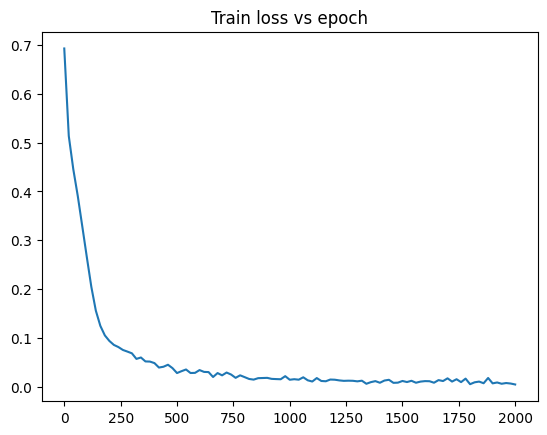

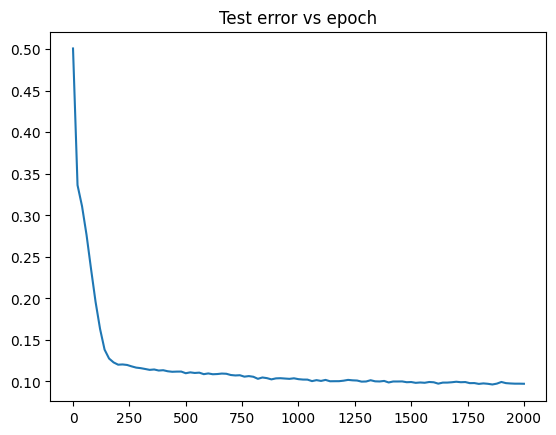

In [68]:
print(len(test_data_labels))
saved_epochs = args.saved_epochs
train_losses = []
test_errors = []
for i in tqdm(range(len(model_list))):
    train_losses.append(give_loss(model_list[i].to(device), train_data, train_data_labels))
    test_errors.append(give_error(model_list[i].to(device), test_data, test_data_labels) )
train_losses = np.array(train_losses)
test_errors = np.array(test_errors)
plt.figure()
plt.plot(saved_epochs[:len(train_losses)],train_losses);
plt.title("Train loss vs epoch");
plt.figure()
plt.plot(saved_epochs[:len(train_losses)],test_errors/len(test_data));
plt.title("Test error vs epoch");
print(test_errors[-1])